# Chronos-Bolt frequency probing — reproduction of Pagani *et al.*

This notebook reproduces the **probing analysis** of

> A. Pagani, M. Cominelli, … F. Cerutti, *"Preliminary Insights in Chronos Frequency
> Data Understanding and Reconstruction"* (arXiv:2605.06361v1),

but the input signals are produced by **this project's own generators**
(**KernelSynth** and **TSMixup**, with the canonical tone-injection convention of
`data/synthetic/tones.py`) instead of the clean sinusoids of the paper.

The pipeline is kept **parametric in the model geometry** `(P, S, fs)` so it works both
for the official `amazon/chronos-bolt-tiny` (P=16, S=16 — the exact configuration of the
paper) **and** for the retrained patch/stride variants of this project.

**What we reproduce**

| Paper | Here |
|-------|------|
| model choice (P,S): official vs. retrained HF variants | §0.1 |
| Fig. 1 — hierarchical frequency splitting (7 binary band tasks) | §1 |
| Fig. 2 — probes: `[REG]` after each **encoder+decoder** block, + output `[REG]` **and** projected head | §3 |
| Fig. 3 — Space-Saving (SV) bars + shuffled & random-init controls | §5 |
| Fig. 4 — task-stratified spectral accuracy heatmap | §6 |
| Fig. 5 — input vs. reconstructed dominant frequency | §7 |
| — (project extra) amplitude-recovery & WQL vs. cpp | §8 |
| — H1/H3 localized readout at the stride-lock frequencies | §9 |

This project distinguishes **two** aliasing effects that the default `P=S=16` model conflates:
the **patch-integration null** (a tone with an integer number of cycles *inside* one patch of
`P` samples, `f = k·fs/P`, integrates to ~0 in the patch embedding) and the **structural
stride-lock** `F_lock = {f = c·fs/S}` (the deliverable's mechanism: `x[n+S]=x[n]` ⇒ consecutive
patches identical). They **coincide only when `S = P`**; selecting an `S≠P` variant in §0.1
separates them and turns every figure into a direct **H2** test.

## 0 — Setup & configuration

In [1]:
import os, sys, json, warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import FancyBboxPatch

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import tqdm

from chronos import BaseChronosPipeline

warnings.filterwarnings("ignore")

# project generators + canonical tone/cpp helpers (single source of truth)
sys.path.insert(0, "../data/synthetic/")
import signalGenerator as sg
from tones import make_tone, cpp as cpp_of, cpp_to_freq

C:\Users\feder\Desktop\patchAliasing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- reproducibility -------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
RNG = np.random.default_rng(SEED)

## 0.1 — Model selection *(patch / stride)*

Choose the model by its `(P, S)` geometry. **`(16, 16)` loads the official
`amazon/chronos-bolt-tiny`** (200k steps, full corpus — the paper's model). **Any other
supported `(P, S)` loads the corresponding retrained variant** from the project's Hugging Face
sweep repo. Because every downstream marker (patch-integration null `k·fs/P` and structural
stride-lock `c·fs/S`) is re-derived from the loaded geometry, switching `STRIDE` here and
re-running is the direct test of **H2** (do the aliasing locations move with `1/S`?).

In [3]:
# ============================================================================
#  CONFIG  —  the only block you normally edit
# ============================================================================
import os
# --- model selection: pick (P, S); the model is loaded in the NEXT cell (testing_lib) ---
PATCH   = int(os.environ.get("PROBE_PATCH", 16))    # patch size  P  (env-overridable: run all models)
STRIDE  = int(os.environ.get("PROBE_STRIDE", 16))   # stride S.  (16,16) -> official; others -> retrained variant

GENERATOR  = "tsmixup"                    # "tsmixup" (light TSMixup, a PRIMARY set in the
                                          #  deliverable) or "kernelsynth" (the OPTIONAL set):
                                          #  the background under the swept probing tones.

FS         = 512          # sampling frequency [Hz]; deliverable convention (Nyquist = 256 Hz)
CONTEXT_LEN = 512         # samples fed as history. NB: bolt-tiny's default context is 2048;
                          # we probe at 512 (the paper convention, for cross-family parity).
BAND       = (2, 250)     # sine sweep [Hz] per the deliverable's Data section (2..250 @ 1 Hz):
                          # a guard band strictly below Nyquist (fs/2 = 256 Hz) to avoid the
                          # degenerate Nyquist tone. The 7 band tasks (paper Fig. 1) span [2,250].

# How the frequency-carrying signal is built from our generators:
#   PURE_SINUSOID = True  -> exact paper input  x_f[n] = sin(2*pi*f*n/fs)
#   PURE_SINUSOID = False -> a generator BACKGROUND (KernelSynth/TSMixup) with the
#                            target tone injected on top at signal-to-background ratio
#                            TONE_SNR (tone dominant so its frequency is recoverable).
PURE_SINUSOID = False    # project setup: generator (TSMixup/KernelSynth) background + injected tone
TONE_SNR      = 4.0       # tone amplitude in units of (unit-variance) background std

# MDL probe
N_PCA = 20                # common subspace for all stages (see §5)
MDL_K = 5                 # prequential chunks

# grid sizes — a fast pass sets PROBE_SMOKE=1 (run_all_models.py --smoke) and shrinks everything
SMOKE = os.environ.get("PROBE_SMOKE", "0") == "1"
FREQ_STEP    = 16 if SMOKE else 1     # dataset frequency step [Hz] (1 Hz -> 249 sine signals)
N_PHASES     = 3  if SMOKE else 10    # phases per frequency (probing dataset)
GEN_LEN      = 128 if SMOKE else 256  # autoregressive rollout length for Fig. 5
N_PHASES_GEN = 2  if SMOKE else 4     # phases per frequency (reconstruction)

OUT = Path(f"outputs/per_model/p{PATCH}-s{STRIDE}"); OUT.mkdir(parents=True, exist_ok=True)
TMP = Path("outputs/_gen_tmp"); TMP.mkdir(parents=True, exist_ok=True)  # shared generators' scratch dir
print("SMOKE run" if SMOKE else "FULL run",
      f"| (P,S) requested = ({PATCH},{STRIDE}) | generator={GENERATOR} | freq step={FREQ_STEP} Hz | phases={N_PHASES}")

FULL run | (P,S) requested = (24,24) | generator=tsmixup | freq step=1 Hz | phases=10


In [4]:
import sys as _sys
_sys.path.insert(0, ".")                    # testing_lib (notebook CWD = chronos/testing)
import testing_lib as tl

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ---- load the frozen model (single source of truth: testing_lib) -----------
# (P,S) = (16,16)  -> the official amazon/chronos-bolt-tiny.
# any other (P,S)  -> the retrained variant, loaded from the LOCAL checkpoint
#   (../models/weights/p{P}-s{S}-seed42, latest) if present, else the Hugging Face sweep repo.
pipeline, MODEL_LABEL = tl.load_pipeline(PATCH, STRIDE, device=DEVICE)
print(f"loaded: {MODEL_LABEL}")

model = pipeline.model
cfg = model.config.chronos_config

P         = cfg["input_patch_size"]      # patch length  (16 for bolt-tiny)
S         = cfg["input_patch_stride"]    # patch stride  (16 for bolt-tiny)
PRED_LEN  = cfg["prediction_length"]     # forecast horizon (64)
QUANTILES = list(cfg["quantiles"])
QIDX      = QUANTILES.index(0.5) if 0.5 in QUANTILES else len(QUANTILES) // 2
N_ENC     = len(model.encoder.block)
N_DEC     = len(model.decoder.block)

if (P, S) != (PATCH, STRIDE):
    print(f"WARNING: requested (P={PATCH},S={STRIDE}) but the loaded model has (P={P},S={S}).")

# --- the TWO aliasing families, and the deliverable's F_lock (their intersection) ---
#   patch-integration null : f = k*fs/P  (a tone fits an integer #cycles INSIDE one patch of
#                                          P samples -> the patch embedding integrates it to ~0)
#   structural stride-lock : f = c*fs/S  (x[n+S]=x[n], consecutive patches identical)
#   F_lock (deliverable eq:flock_set) : the INTERSECTION {c*fs/S} & {k*fs/P}
F_PATCH  = FS / P                        # patch  frequency  f_p = fs/P
F_STRIDE = FS / S                        # stride frequency  f_s/S
def patch_nulls(fmax):   return [k * FS / P for k in range(1, int(fmax * P / FS) + 1)]
def stride_locks(fmax):  return [c * FS / S for c in range(1, int(fmax * S / FS) + 1)]
def f_lock(fmax):        # F_lock = {c*fs/S} intersect {k*fs/P}  (both conditions hold)
    pset = {round(x, 6) for x in patch_nulls(fmax)}
    return [x for x in stride_locks(fmax) if round(x, 6) in pset]

print(json.dumps(cfg, indent=2)[:400], "...")
print(f"\nP={P}  S={S}  fs={FS} Hz")
print(f"encoder blocks = {N_ENC}, decoder blocks = {N_DEC}  "
      f"(probe stages: enc_0..{N_ENC-1}, dec_0..{N_DEC-1}, output_reg, output_head)")
print(f"patch-integration nulls  (k*fs/P): {[int(x) for x in patch_nulls(BAND[1])]} Hz")
print(f"structural stride-locks  (c*fs/S): {[int(x) for x in stride_locks(BAND[1])]} Hz")
print(f"F_lock (intersection)            : {[int(x) for x in f_lock(BAND[1])]} Hz")
print("  -> stride-locks and patch-nulls COINCIDE for P=S; they SEPARATE for S!=P (the H3 test).")

loaded: p24-s24 (local checkpoint-100000)


{
  "context_length": 2048,
  "input_patch_size": 24,
  "input_patch_stride": 24,
  "prediction_length": 64,
  "quantiles": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
  ],
  "use_reg_token": true
} ...

P=24  S=24  fs=512 Hz
encoder blocks = 4, decoder blocks = 4  (probe stages: enc_0..3, dec_0..3, output_reg, output_head)
patch-integration nulls  (k*fs/P): [21, 42, 64, 85, 106, 128, 149, 170, 192, 213, 234] Hz
structural stride-locks  (c*fs/S): [21, 42, 64, 85, 106, 128, 149, 170, 192, 213, 234] Hz
F_lock (intersection)            : [21, 42, 64, 85, 106, 128, 149, 170, 192, 213, 234] Hz
  -> stride-locks and patch-nulls COINCIDE for P=S; they SEPARATE for S!=P (the H3 test).


## 1 — Hierarchical frequency splitting  *(paper Fig. 1)*

The operational band `[2, 250] Hz` is recursively split into **seven binary discrimination
tasks**, one per internal node of a depth-2 binary tree. Each task asks a single
yes/no question: *is the tone frequency in the lower or the upper half of this node's band?*

```
                         Mid  [2,250]  (split @126)
              L [2,126] (@64)                 H [127,250] (@188)
      LL [2,64] (@33)  LH [65,126] (@95)  HL [127,188] (@157)  HH [189,250] (@219)
```

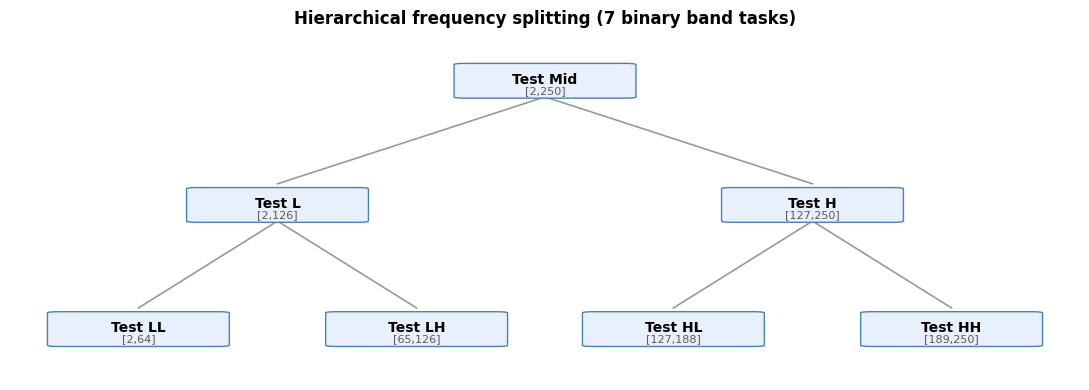

In [5]:
# Each task: (name, band_lo, band_hi, boundary).  label = 0 if f<=boundary else 1.
# Boundaries are the band midpoints -> exactly the partition drawn in the paper's Fig. 1.
TASKS = [
    ("LL",   2,  64,  33),
    ("L",    2, 126,  64),
    ("LH",  65, 126,  95),
    ("Mid",  2, 250, 126),
    ("HL", 127, 188, 157),
    ("H",  127, 250, 188),
    ("HH", 189, 250, 219),
]  # ordered by ascending threshold, as in Fig. 3
TASK_NAMES = [t[0] for t in TASKS]

def task_label(freq, boundary):
    return int(freq > boundary)

# ---- redraw Fig. 1 (the splitting tree) -----------------------------------
def draw_hierarchy():
    nodes = {  # name: (x, y, band)
        "Mid": (0.5, 3, "[2,250]"),
        "L":   (0.25, 2, "[2,126]"), "H": (0.75, 2, "[127,250]"),
        "LL":  (0.12, 1, "[2,64]"), "LH": (0.38, 1, "[65,126]"),
        "HL":  (0.62, 1, "[127,188]"), "HH": (0.88, 1, "[189,250]"),
    }
    edges = [("Mid","L"),("Mid","H"),("L","LL"),("L","LH"),("H","HL"),("H","HH")]
    fig, ax = plt.subplots(figsize=(11, 4))
    for a, b in edges:
        ax.plot([nodes[a][0], nodes[b][0]], [nodes[a][1]-0.12, nodes[b][1]+0.18],
                color="0.6", lw=1.2, zorder=1)
    for name, (x, y, band) in nodes.items():
        ax.add_patch(FancyBboxPatch((x-0.075, y-0.12), 0.15, 0.26,
                     boxstyle="round,pad=0.01", fc="#e8f0fe", ec="steelblue", zorder=2))
        ax.text(x, y+0.02, f"Test {name}", ha="center", va="center",
                fontsize=10, fontweight="bold", zorder=3)
        ax.text(x, y-0.07, band, ha="center", va="center", fontsize=8, color="0.35", zorder=3)
    ax.set_xlim(0, 1); ax.set_ylim(0.6, 3.4); ax.axis("off")
    ax.set_title("Hierarchical frequency splitting (7 binary band tasks)", fontweight="bold")
    plt.tight_layout(); plt.savefig(OUT/"FIG1_hierarchy.png", dpi=140, bbox_inches="tight"); plt.show()

draw_hierarchy()

## 2 — Signal source: generator-driven tones

For a target frequency `f` we build a length-`CONTEXT_LEN` context on the `fs` grid:

* `PURE_SINUSOID = True` → the paper's exact input `x_f[n] = sin(2π f n / fs)`.
* `PURE_SINUSOID = False` (default) → a **KernelSynth / TSMixup background** with the tone
  **injected** on top (same convention as the project's generators), at a
  signal-to-background ratio `TONE_SNR` so the tone remains the dominant spectral component.

Setting `TONE_SNR → ∞` (or `PURE_SINUSOID=True`) recovers the paper exactly; a finite SNR
is the more realistic, project-specific stress test: *does the model still expose the
frequency when the tone rides on a rich synthetic background?*

In [6]:
def generator_background(n, seed):
    """A background realisation from the chosen project generator (no injection)."""
    if GENERATOR == "kernelsynth":
        p = {"J": 5, "l_syn": n, "fs": FS, "jitter": 1e-4, "P": P}
        gen = sg.runKernelSynth(p, seed, TMP)
    else:
        # light-TSMixup spec (deliverable Alg. 1): K=10, alpha=1.5, sinusoidal pool
        p = {"K": 10, "alpha": 1.5, "l_min": n, "l_max": n, "fs": FS, "P": P,
             "t_lengths": [n // 2, n, n]}
        gen = sg.runTSMixup(p, seed, TMP)
    return np.asarray(gen.generate(), float).ravel()[:n]

def make_freq_signal(freq, phase, seed):
    """Context whose dominant component is a tone at `freq` (Hz), phase `phase` (rad)."""
    if PURE_SINUSOID:
        return make_tone(freq, FS, CONTEXT_LEN, amplitude=1.0, phase=phase).astype(np.float32)
    bg = generator_background(CONTEXT_LEN, seed)
    s = bg.std()
    bg = bg / s if s > 1e-8 else bg                       # unit-variance background
    tone = make_tone(freq, FS, CONTEXT_LEN, amplitude=TONE_SNR, phase=phase)
    return (bg + tone).astype(np.float32)

# one demo context (a 64 Hz tone) used by the capture smoke-check in the next cell
x_demo = make_freq_signal(64.0, 0.0, seed=0)

## 3 — Hidden-state capture: the 256-d `[REG]` vector  *(paper Fig. 2, deliverable §Probing)*

Per the deliverable we probe the **single 256-d `[REG]` vector after each encoder *and* decoder
block**, plus the output layer — *avoiding the dimensionality mismatch of probing the full
flattened patch sequence*. Concretely, per the Chronos-Bolt architecture:

* **encoder blocks** emit `[batch, num_patches+1, 256]`; the `[REG]` token is **appended**, so it
  is the **last** token → we take `enc[:, -1, :]`.
* **decoder blocks** emit a **single** query token `[batch, 1, 256]` → that *is* the `[REG]` vector.
* **output layer** — we keep **two** stages here, because the deliverable and the paper probe
  different points and both are informative:
  * `output_reg` = the **256-d `[REG]` input** of the projection (deliverable's spec — an
    internal representation);
  * `output_head` = the **final projected quantile output** (the paper's Fig. 3 `h4`). This is
    the only stage where the paper's **compression drop** appears, so it localises the
    attenuation to the *projection* itself (the internal `[REG]` does not drop).

The internal `[REG]` stages are all 256-d and directly comparable. We also switch from
independent random phases to the paper's **non-redundant phase sampling**
`S_f = min(fs/gcd(f,fs) − 1, N)`.

In [7]:
STAGES = ([f"enc_{k}" for k in range(N_ENC)]
          + [f"dec_{k}" for k in range(N_DEC)]
          + ["output_reg", "output_head"])
# output_reg  = 256-d [REG] vector (pre-projection)   -> deliverable's spec (internal repr.)
# output_head = final projected quantile output (576-d) -> the paper's Fig. 3 h4 (shows the drop)

def _reg_vector(o, which):
    """Extract the single 256-d [REG] vector from a block output/input.
    'last'   -> encoder blocks: the [REG] token is appended (last position).
    'single' -> decoder blocks: the decoder emits a single query token.
    """
    a = o[0] if isinstance(o, tuple) else o
    a = a.detach().float().cpu().numpy()
    if a.ndim == 3:          # [batch, tokens, d] -> [tokens, d]
        a = a[0]
    if a.ndim == 1:
        return a
    return a[-1] if which == "last" else a[0]

@torch.no_grad()
def capture_with(pipe, context):
    """Return {stage: 256-d [REG] vector} for one context, using `pipe`'s model."""
    mdl = pipe.model
    cap, handles = {}, []
    def save(key, which):
        def hook(m, i, o): cap[key] = _reg_vector(o, which)
        return hook
    def save_input(key):     # 256-d INPUT of the output layer (final [REG], pre-projection)
        def hook(m, i, o): cap[key] = _reg_vector(i[0], "single")
        return hook
    for k, b in enumerate(mdl.encoder.block):
        handles.append(b.register_forward_hook(save(f"enc_{k}", "last")))
    for k, b in enumerate(mdl.decoder.block):
        handles.append(b.register_forward_hook(save(f"dec_{k}", "single")))
    if hasattr(mdl, "output_patch_embedding"):
        # 256-d [REG] INPUT (deliverable) AND the 576-d projected OUTPUT (paper's h4)
        handles.append(mdl.output_patch_embedding.register_forward_hook(save_input("output_reg")))
        handles.append(mdl.output_patch_embedding.register_forward_hook(save("output_head", "single")))
    try:
        x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
        pipe.predict(x, prediction_length=PRED_LEN)
    finally:
        for h in handles:
            h.remove()
    return cap

def capture_hidden(context):
    return capture_with(pipeline, context)

# non-redundant phase sampling S_f = min(fs/gcd(f,fs) - 1, N)  (paper Eq. 6)
from math import gcd
def phases_Sf(freq, n_max):
    period = FS // gcd(int(round(freq)), int(FS))       # distinct sample shifts
    n_ph = int(np.clip(period - 1, 1, n_max))
    ks = np.linspace(0, period, n_ph, endpoint=False)   # spread over one period
    return 2 * np.pi * freq * ks / FS

# smoke check
_c = capture_hidden(x_demo)
print("captured stages:", list(_c.keys()))
print("feature dims:", {k: v.shape for k, v in _c.items()})
print("example S_f phase counts:", {int(f): len(phases_Sf(f, N_PHASES)) for f in (7, 32, 64, 96)})

captured stages: ['enc_0', 'enc_1', 'enc_2', 'enc_3', 'dec_0', 'dec_1', 'dec_2', 'dec_3', 'output_reg', 'output_head']
feature dims: {'enc_0': (256,), 'enc_1': (256,), 'enc_2': (256,), 'enc_3': (256,), 'dec_0': (256,), 'dec_1': (256,), 'dec_2': (256,), 'dec_3': (256,), 'output_reg': (256,), 'output_head': (576,)}
example S_f phase counts: {7: 10, 32: 10, 64: 7, 96: 10}


## 4 — Build the probing dataset

We sweep the band on a `FREQ_STEP`-Hz grid, using the **non-redundant phases** `S_f` per
frequency (patch-aligned frequencies get fewer, genuinely distinct phases), generate one
context per `(f, φ)` and record its nine `[REG]` feature vectors. Every task in §5–§6 reuses
these same features (only the label mapping changes).

In [8]:
FREQS = np.arange(BAND[0], BAND[1] + 1, FREQ_STEP, dtype=float)

feat = {s: [] for s in STAGES}
lab_freq, lab_phase = [], []
seed_ctr = 1000
for f in tqdm.tqdm(FREQS, desc="dataset"):
    for ph in phases_Sf(f, N_PHASES):
        x = make_freq_signal(f, ph, seed=seed_ctr); seed_ctr += 1
        cap = capture_hidden(x)
        for s in STAGES:
            feat[s].append(cap[s])
        lab_freq.append(f); lab_phase.append(ph)

X = {s: np.vstack(feat[s]) for s in STAGES}
lab_freq = np.asarray(lab_freq)
print(f"{len(FREQS)} frequencies, {len(lab_freq)} contexts (S_f non-redundant phases)")
print("feature matrices:", {s: X[s].shape for s in STAGES})

dataset:   0%|          | 0/249 [00:00<?, ?it/s]

dataset:   0%|          | 1/249 [00:00<00:34,  7.10it/s]

dataset:   1%|          | 2/249 [00:00<00:39,  6.29it/s]

dataset:   1%|          | 3/249 [00:00<00:37,  6.52it/s]

dataset:   2%|▏         | 4/249 [00:00<00:37,  6.53it/s]

...

dataset:  99%|█████████▉| 247/249 [00:31<00:00,  7.47it/s]

dataset: 100%|█████████▉| 248/249 [00:31<00:00,  8.00it/s]

dataset: 100%|██████████| 249/249 [00:32<00:00,  8.41it/s]

dataset: 100%|██████████| 249/249 [00:32<00:00,  7.78it/s]

249 frequencies, 2477 contexts (S_f non-redundant phases)
feature matrices: {'enc_0': (2477, 256), 'enc_1': (2477, 256), 'enc_2': (2477, 256), 'enc_3': (2477, 256), 'dec_0': (2477, 256), 'dec_1': (2477, 256), 'dec_2': (2477, 256), 'dec_3': (2477, 256), 'output_reg': (2477, 256), 'output_head': (2477, 576)}


## 5 — MDL probing → Space Saving  *(paper Fig. 3)*

For each task we train a lightweight **prequential-MDL** probe on every stage and report the
**Space Saving** (paper Eq. 7)

$$\mathrm{SV} = 1 - \dfrac{L(D)}{L_\text{uniform}(D)},\qquad L_\text{uniform}=N\ \text{bits (fair coin)}.$$

`SV → 1` ⇒ the labels are highly compressible from that representation (strong linear
separability). We use **two controls** (deliverable §Probing):

* **shuffled labels** — SV ≤ 0 confirms the probe does not memorise noise;
* **random-init model** — same architecture, untrained weights; a low SV here confirms the
  frequency information is *learned*, not a mere artefact of the architecture / random
  projections.

The pipeline is `StandardScaler → PCA(20) → LogisticRegression`, a common well-conditioned
subspace so SV is comparable across stages.

In [9]:
def mdl_codelength(Xf, y, K=MDL_K, n_pca=N_PCA):
    """Prequential MDL codelength (bits) for a binary set (Xf, y)."""
    r = np.random.default_rng(SEED)
    idx = r.permutation(len(y)); Xf, y = Xf[idx], y[idx]
    ch = np.array_split(np.arange(len(y)), K)
    L = len(ch[0]) * 1.0                                  # first chunk: 1 bit/example
    for k in range(1, K):
        tr = np.concatenate(ch[:k]); te = ch[k]
        if len(te) == 0:                         # empty prequential chunk (tiny dataset)
            continue
        if len(np.unique(y[tr])) < 2:            # can't fit a probe yet -> uniform code
            L += len(te) * 1.0
            continue
        n_comp = max(2, min(n_pca, Xf.shape[1], len(tr) - 1))
        clf = make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                            LogisticRegression(max_iter=2000))
        clf.fit(Xf[tr], y[tr])
        # map probe classes back to label ids (a fold may miss a class in predict_proba)
        proba = clf.predict_proba(Xf[te])
        cls = list(clf.named_steps["logisticregression"].classes_)
        p = np.array([proba[i, cls.index(y[te][i])] if y[te][i] in cls else 1e-6
                      for i in range(len(te))])
        L += -np.log2(np.clip(p, 1e-6, 1)).sum()
    return L

def space_saving(Xf, y):
    return 1 - mdl_codelength(Xf, y) / len(y)

# SV and shuffled-control SV for every (stage, task)
SV      = {s: {} for s in STAGES}
SV_ctrl = {s: {} for s in STAGES}
for (name, lo, hi, bnd) in tqdm.tqdm(TASKS, desc="MDL tasks"):
    mask = (lab_freq >= lo) & (lab_freq <= hi)
    y = np.array([task_label(f, bnd) for f in lab_freq[mask]])
    y_ctrl = RNG.permutation(y)
    for s in STAGES:
        Xs = X[s][mask]
        SV[s][name]      = space_saving(Xs, y)
        SV_ctrl[s][name] = space_saving(Xs, y_ctrl)

# ---- random-init control: same architecture, untrained weights -----------
import copy
SV_rand = {s: {} for s in STAGES}
try:
    rand_pipe = copy.deepcopy(pipeline)
    rand_pipe.model = type(pipeline.model)(copy.deepcopy(pipeline.model.config)).eval()
    rstep = max(FREQ_STEP * 4, 4)                      # coarse grid (it is only a control)
    rfreqs = np.arange(BAND[0], BAND[1] + 1, rstep, dtype=float)
    rfeat = {s: [] for s in STAGES}; rlab = []; rseed = 90000
    for f in tqdm.tqdm(rfreqs, desc="rand-init ctrl"):
        for ph in phases_Sf(f, max(2, N_PHASES // 2)):
            cap = capture_with(rand_pipe, make_freq_signal(f, ph, seed=rseed)); rseed += 1
            for s in STAGES: rfeat[s].append(cap[s])
            rlab.append(f)
    rlab = np.asarray(rlab); Xr = {s: np.vstack(rfeat[s]) for s in STAGES}
    for (name, lo, hi, bnd) in TASKS:
        m = (rlab >= lo) & (rlab <= hi); yr = np.array([task_label(f, bnd) for f in rlab[m]])
        if len(np.unique(yr)) < 2: continue
        for s in STAGES: SV_rand[s][name] = space_saving(Xr[s][m], yr)
    HAVE_RAND = True
except Exception as e:
    print("random-init control unavailable:", e); HAVE_RAND = False

MDL tasks:   0%|          | 0/7 [00:00<?, ?it/s]

MDL tasks:  14%|█▍        | 1/7 [00:02<00:14,  2.49s/it]

MDL tasks:  29%|██▊       | 2/7 [00:05<00:13,  2.71s/it]

MDL tasks:  43%|████▎     | 3/7 [00:08<00:10,  2.73s/it]

MDL tasks:  57%|█████▋    | 4/7 [00:11<00:08,  2.86s/it]

...

rand-init ctrl:  83%|████████▎ | 52/63 [00:01<00:00, 26.96it/s]

rand-init ctrl:  89%|████████▉ | 56/63 [00:02<00:00, 27.97it/s]

rand-init ctrl:  94%|█████████▎| 59/63 [00:02<00:00, 28.26it/s]

rand-init ctrl:  98%|█████████▊| 62/63 [00:02<00:00, 28.04it/s]

rand-init ctrl: 100%|██████████| 63/63 [00:02<00:00, 27.10it/s]

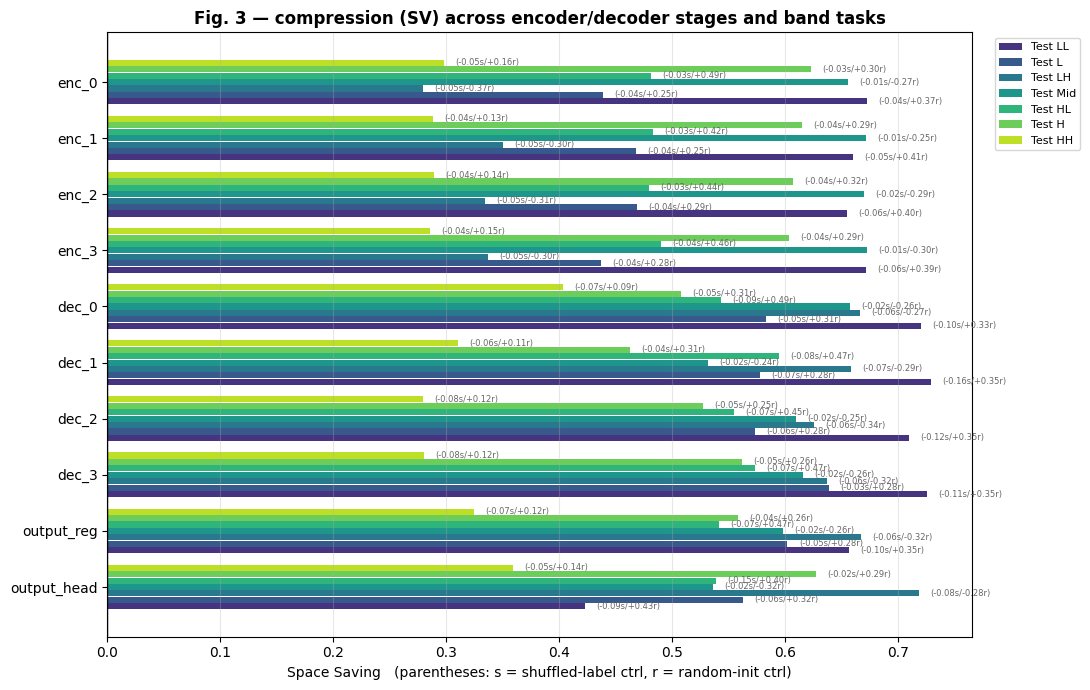

stage             SV  shuffled  rand-init
enc_0         +0.493    -0.035     +0.131
enc_1         +0.505    -0.038     +0.135
enc_2         +0.501    -0.042     +0.141
enc_3         +0.500    -0.041     +0.139
dec_0         +0.583    -0.062     +0.144
dec_1         +0.552    -0.070     +0.142
dec_2         +0.554    -0.066     +0.122
dec_3         +0.576    -0.059     +0.130
output_reg    +0.564    -0.058     +0.128
output_head   +0.538    -0.066     +0.142

learned signal (SV_trained - SV_rand) per stage:
  enc_0        +0.362
  enc_1        +0.370
  enc_2        +0.360
  enc_3        +0.361
  dec_0        +0.439
  dec_1        +0.411
  dec_2        +0.433
  dec_3        +0.447
  output_reg   +0.437
  output_head  +0.396   <-- only stage with a learned drop


In [10]:
# ---- Fig. 3 : horizontal grouped bar chart --------------------------------
stage_order = STAGES[::-1]                     # output_layer at the bottom like the paper
n_task = len(TASKS)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, n_task))
bar_h = 0.8 / n_task

fig, ax = plt.subplots(figsize=(11, 7))
for gi, s in enumerate(stage_order):
    for ti, name in enumerate(TASK_NAMES):
        yc = gi + (ti - n_task/2) * bar_h + bar_h/2
        val = SV[s][name]
        ax.barh(yc, val, height=bar_h*0.95, color=colors[ti],
                label=f"Test {name}" if gi == 0 else None)
        r = SV_rand[s].get(name)
        ann = f"({SV_ctrl[s][name]:+.2f}s" + (f"/{r:+.2f}r)" if r is not None else "s)")
        ax.text(max(val, 0) + 0.01, yc, ann, va="center", fontsize=6, color="0.4")

ax.set_yticks(range(len(stage_order)))
ax.set_yticklabels(stage_order)
ax.set_xlabel("Space Saving   (parentheses: s = shuffled-label ctrl, r = random-init ctrl)")
ax.set_title("Fig. 3 — compression (SV) across encoder/decoder stages and band tasks",
             fontweight="bold")
ax.axvline(0, color="k", lw=1)
ax.grid(axis="x", alpha=.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"FIG3_space_saving.png", dpi=140, bbox_inches="tight"); plt.show()

print(f"{'stage':12s} {'SV':>7s} {'shuffled':>9s} {'rand-init':>10s}")
for s in STAGES:
    r = [v for v in SV_rand[s].values()]
    rr = f"{np.mean(r):+.3f}" if r else "   n/a"
    print(f"{s:12s} {np.mean(list(SV[s].values())):+7.3f} "
          f"{np.mean(list(SV_ctrl[s].values())):+9.3f} {rr:>10s}")

# ---- S1: is the band information LEARNED?  learned gap = SV_trained - SV_rand ----
print("\nlearned signal (SV_trained - SV_rand) per stage:")
for s in STAGES:
    r = list(SV_rand[s].values())
    if not r:
        print(f"  {s:12s}   n/a"); continue
    g = np.mean(list(SV[s].values())) - np.mean(r)
    print(f"  {s:12s} {g:+.3f}" + ("   <-- only stage with a learned drop" if s == "output_head" else ""))


### Interpretation — is the frequency information *learned*?  *(random-init control)*

The **random-init** control (identical architecture, untrained weights) reaches **almost the same
SV as the trained model on every internal stage** (`enc_*`, `dec_*`, `output_reg`). Band-frequency
separability is therefore largely an **architectural** property: a random linear map over a patch
already exposes the band (a random-features / Johnson–Lindenstrauss effect), so a high internal SV
is **not** evidence that training encoded the frequency. The **only** stage where training makes a
measurable difference is the projected output head (`output_head`): there the trained SV **drops**
while the random one stays high — see the *learned gap* printed above. Consequently, for this task
the informative, learned signal lives at `output_head`, and the internal-block MDL should be read
as a (saturated) capacity probe, not as proof of learned frequency encoding.

## 6 — Task-stratified spectral accuracy heatmap  *(paper Fig. 4)*

Per-frequency classification accuracy for each task, obtained with cross-validated
predictions on the **projected output head** (`output_head`, the paper's h4 — where the
spectral dependence and the aliasing dips are visible). Cells are thresholded into
**<0.6 (red) / 0.6–0.9 (yellow) / ≥0.9 (green)**; frequencies outside a task's band are grey.
Two vertical marker families are overlaid: **patch-integration nulls** `k·fs/P` (solid blue)
and **structural stride-locks** `c·fs/S` (dashed purple, the deliverable's `F_lock`). They
**coincide for P=S** and separate for `S≠P` — the visual form of **H2**.

accuracy:   0%|          | 0/7 [00:00<?, ?it/s]

accuracy:  14%|█▍        | 1/7 [00:00<00:00,  8.94it/s]

accuracy:  29%|██▊       | 2/7 [00:00<00:00,  5.59it/s]

accuracy:  43%|████▎     | 3/7 [00:00<00:00,  6.44it/s]

accuracy:  57%|█████▋    | 4/7 [00:00<00:00,  5.25it/s]

accuracy:  71%|███████▏  | 5/7 [00:00<00:00,  5.94it/s]

accuracy:  86%|████████▌ | 6/7 [00:01<00:00,  5.55it/s]

accuracy: 100%|██████████| 7/7 [00:01<00:00,  5.97it/s]

accuracy: 100%|██████████| 7/7 [00:01<00:00,  5.92it/s]

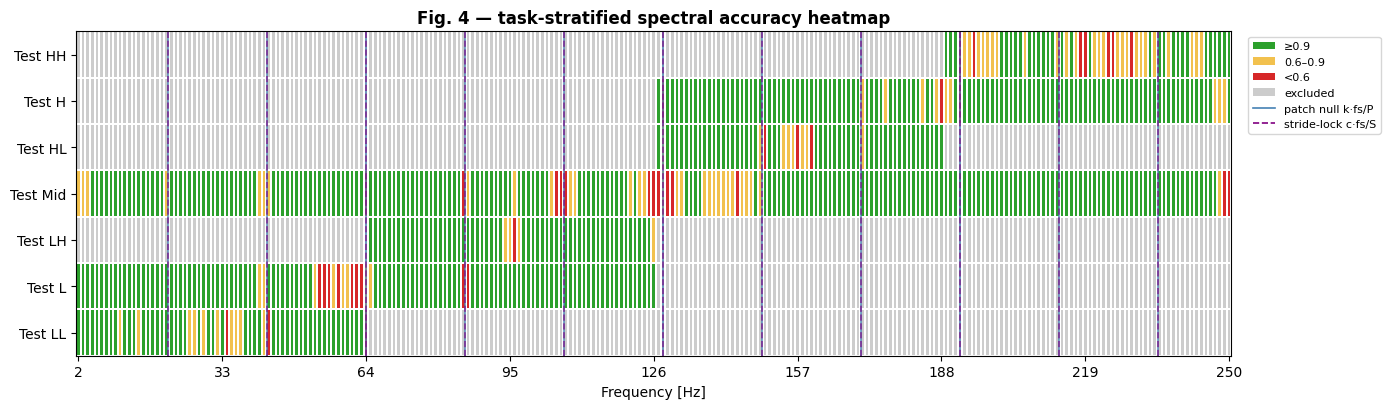

In [11]:
ACC_STAGE = "output_head"     # the paper's h4 (projected output) — where the spectral drop lives
uniq_freqs = FREQS
acc = np.full((len(TASKS), len(uniq_freqs)), np.nan)   # rows=tasks, cols=freq

for ri, (name, lo, hi, bnd) in enumerate(tqdm.tqdm(TASKS, desc="accuracy")):
    mask = (lab_freq >= lo) & (lab_freq <= hi)
    y = np.array([task_label(f, bnd) for f in lab_freq[mask]])
    Xs = X[ACC_STAGE][mask]; fm = lab_freq[mask]
    if len(np.unique(y)) < 2:
        continue
    n_splits = min(5, np.bincount(y).min())
    if n_splits < 2:
        continue
    train_min = len(y) - int(np.ceil(len(y) / n_splits))   # smallest training fold
    n_comp = max(2, min(N_PCA, Xs.shape[1], train_min - 1))
    clf = make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                        LogisticRegression(max_iter=2000))
    yhat = cross_val_predict(clf, Xs, y, cv=StratifiedKFold(n_splits, shuffle=True, random_state=SEED))
    for ci, f in enumerate(uniq_freqs):
        sel = fm == f
        if sel.any():
            acc[ri, ci] = (yhat[sel] == y[sel]).mean()

# discrete colour map: grey (nan), red (<0.6), yellow (0.6-0.9), green (>=0.9)
cat = np.full_like(acc, -1.0)
cat[acc < 0.6] = 0; cat[(acc >= 0.6) & (acc < 0.9)] = 1; cat[acc >= 0.9] = 2
cmap = ListedColormap(["#cccccc", "#d62728", "#f2c14e", "#2ca02c"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.pcolormesh(np.arange(len(uniq_freqs)+1), np.arange(len(TASKS)+1),
              cat, cmap=cmap, norm=norm, edgecolors="white", linewidth=.3)
# aliasing markers: patch-integration nulls (k*fs/P, solid) & stride-locks (c*fs/S, dashed)
def _xpos(fk): return np.interp(fk, uniq_freqs, np.arange(len(uniq_freqs))) + 0.5
for fk in patch_nulls(BAND[1]):  ax.axvline(_xpos(fk), color="steelblue", lw=1.2, alpha=.85)
for fk in stride_locks(BAND[1]): ax.axvline(_xpos(fk), color="purple", lw=1.2, ls="--", alpha=.7)
ax.set_yticks(np.arange(len(TASKS))+0.5); ax.set_yticklabels([f"Test {t[0]}" for t in TASKS])
xt = np.linspace(0, len(uniq_freqs)-1, 9).astype(int)
ax.set_xticks(xt+0.5); ax.set_xticklabels([int(uniq_freqs[i]) for i in xt])
ax.set_xlabel("Frequency [Hz]")
ax.set_title("Fig. 4 — task-stratified spectral accuracy heatmap", fontweight="bold")
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[Patch(fc="#2ca02c", label="≥0.9"), Patch(fc="#f2c14e", label="0.6–0.9"),
                   Patch(fc="#d62728", label="<0.6"), Patch(fc="#cccccc", label="excluded"),
                   Line2D([0],[0], color="steelblue", lw=1.2, label="patch null k·fs/P"),
                   Line2D([0],[0], color="purple", lw=1.2, ls="--", label="stride-lock c·fs/S")],
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"FIG4_accuracy_heatmap.png", dpi=140, bbox_inches="tight"); plt.show()

## 7 — Reconstruction: input vs. dominant output frequency  *(paper Fig. 5)*

For every input frequency we roll the model out autoregressively (feeding its 64-step median
forecast back into the context) to `GEN_LEN` samples, then estimate the **dominant generated
frequency** as `argmax_k |DFT(x̂)|`. Averaged over phases, we plot the mean generated frequency
(± std) against the ideal diagonal. The patch-aliasing harmonics `k·f_p` are overlaid: where
input tones phase-lock to the patch grid the reconstruction is expected to break down.

> *Supporting analysis.* This reconstruction view comes from the paper's closed-loop generation
> section. It is **not** one of the deliverable's stated probing metrics — those are online
> codelength/SV (§5), forecast **amplitude recovery** and **WQL** (§8), which drive H1/H3.

In [12]:
@torch.no_grad()
def forecast_median(context, horizon=PRED_LEN):
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    out = pipeline.predict(x, prediction_length=horizon)[0].cpu().numpy()
    return out[QIDX]

def rollout(context, total=GEN_LEN):
    ctx = list(np.asarray(context, float)); gen = []
    while len(gen) < total:
        step = forecast_median(np.asarray(ctx[-CONTEXT_LEN:]))
        gen.extend(step.tolist()); ctx.extend(step.tolist())
    return np.asarray(gen[:total])

def dominant_freq(x):
    x = np.asarray(x, float) - np.mean(x)
    mag = np.abs(np.fft.rfft(x))
    f = np.fft.rfftfreq(len(x), d=1/FS)
    return f[np.argmax(mag)]

recon_f = FREQS[FREQS < FS / 2]      # amplitude view is meaningless at/above Nyquist
mean_out, std_out = [], []
for f in tqdm.tqdm(recon_f, desc="reconstruction"):
    outs = []
    for j, ph in enumerate(phases_Sf(f, N_PHASES_GEN)):
        x = make_freq_signal(f, ph, seed=5000 + int(f)*10 + j)
        outs.append(dominant_freq(rollout(x)))
    mean_out.append(np.mean(outs)); std_out.append(np.std(outs))
mean_out = np.array(mean_out); std_out = np.array(std_out)

reconstruction:   0%|          | 0/249 [00:00<?, ?it/s]

reconstruction:   0%|          | 1/249 [00:00<00:43,  5.75it/s]

reconstruction:   1%|          | 2/249 [00:00<00:40,  6.05it/s]

reconstruction:   1%|          | 3/249 [00:00<00:39,  6.30it/s]

reconstruction:   2%|▏         | 4/249 [00:00<00:38,  6.44it/s]

...

reconstruction:  99%|█████████▉| 246/249 [00:36<00:00,  6.61it/s]

reconstruction:  99%|█████████▉| 247/249 [00:36<00:00,  6.71it/s]

reconstruction: 100%|█████████▉| 248/249 [00:36<00:00,  6.75it/s]

reconstruction: 100%|██████████| 249/249 [00:37<00:00,  6.80it/s]

reconstruction: 100%|██████████| 249/249 [00:37<00:00,  6.72it/s]

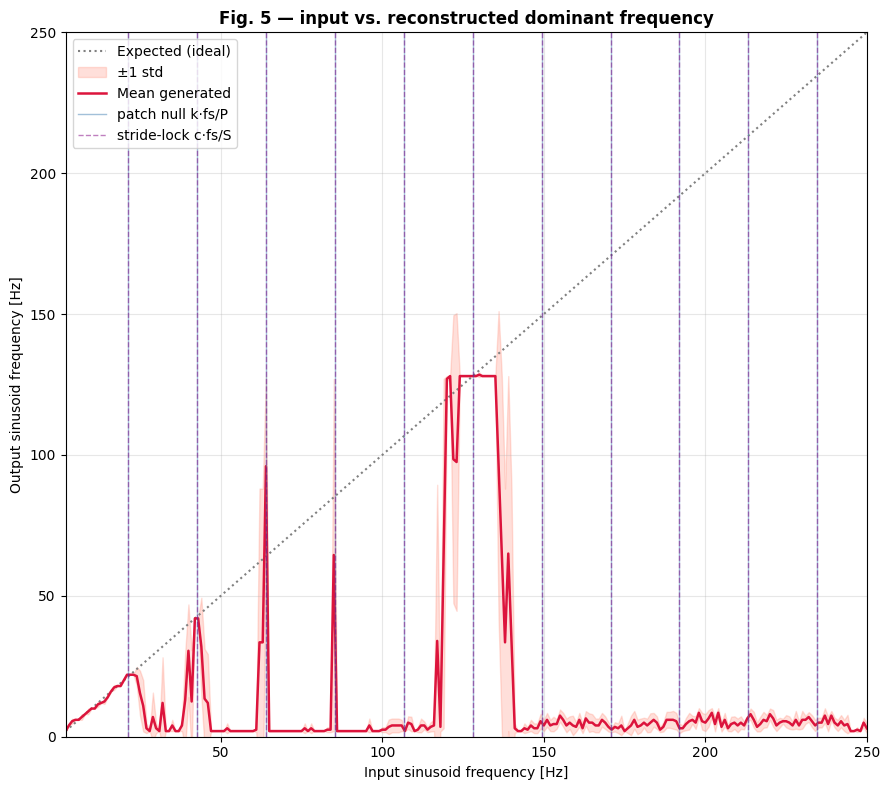

Spectral RMSE (mean generated vs input) = 136.45 Hz


In [13]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([BAND[0], BAND[1]], [BAND[0], BAND[1]], ls=":", color="0.5", label="Expected (ideal)")
ax.fill_between(recon_f, mean_out-std_out, mean_out+std_out, color="tomato", alpha=.2, label="±1 std")
ax.plot(recon_f, mean_out, color="crimson", lw=1.8, label="Mean generated")
for j, fk in enumerate(patch_nulls(BAND[1])):
    ax.axvline(fk, color="steelblue", lw=1, alpha=.5, label="patch null k·fs/P" if j==0 else None)
for j, fk in enumerate(stride_locks(BAND[1])):
    ax.axvline(fk, color="purple", lw=1, ls="--", alpha=.5, label="stride-lock c·fs/S" if j==0 else None)
ax.set_xlabel("Input sinusoid frequency [Hz]"); ax.set_ylabel("Output sinusoid frequency [Hz]")
ax.set_title("Fig. 5 — input vs. reconstructed dominant frequency", fontweight="bold")
ax.set_xlim(BAND); ax.set_ylim(0, BAND[1]); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"FIG5_reconstruction.png", dpi=140, bbox_inches="tight"); plt.show()

rmse = float(np.sqrt(np.mean((mean_out - recon_f)**2)))
print(f"Spectral RMSE (mean generated vs input) = {rmse:.2f} Hz")

## 8 — Reconstruction on the generated signals  *(paper Fig. 5, applied to our set)*

The sweep above builds the labelled probing dataset (the paper's method). Here we instead run
the model over **every generated signal** in `../data/synthetic/signals/` — the actual
KernelSynth / TSMixup realisations with an injected tone at a known frequency — and ask the
same Fig. 5 question **per signal**: does the injected tone survive the forecast, and where
does the output's dominant frequency land? Each signal's `cpp = f·P/fs` is computed from its
own `fs` (parsed from the filename). This is the structural-aliasing test on the real signals.

16 generated signals in ..\data\synthetic\signals

   freq   fs   cpp recovery   inDom  outDom  signal
  112.0  512  5.25    0.002   112.0   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
  128.0  512  6.00    0.846   128.0   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   32.0  512  1.50    0.030    32.0     8.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   48.0  512  2.25    0.062    48.0    40.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   64.0  512  3.00    0.056     0.9   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   80.0  512  3.75    0.046     0.9   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
  112.0  512  5.25    0.012     0.9   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   64.0  512  3.00    0.154    64.0   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   80.0  512  3.75    0.004    80.0   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001__
   96.0  512  4.50    0.005    96.0   128.0  KernelSynth_J5_l_syn576_fs512_jitter0.0001

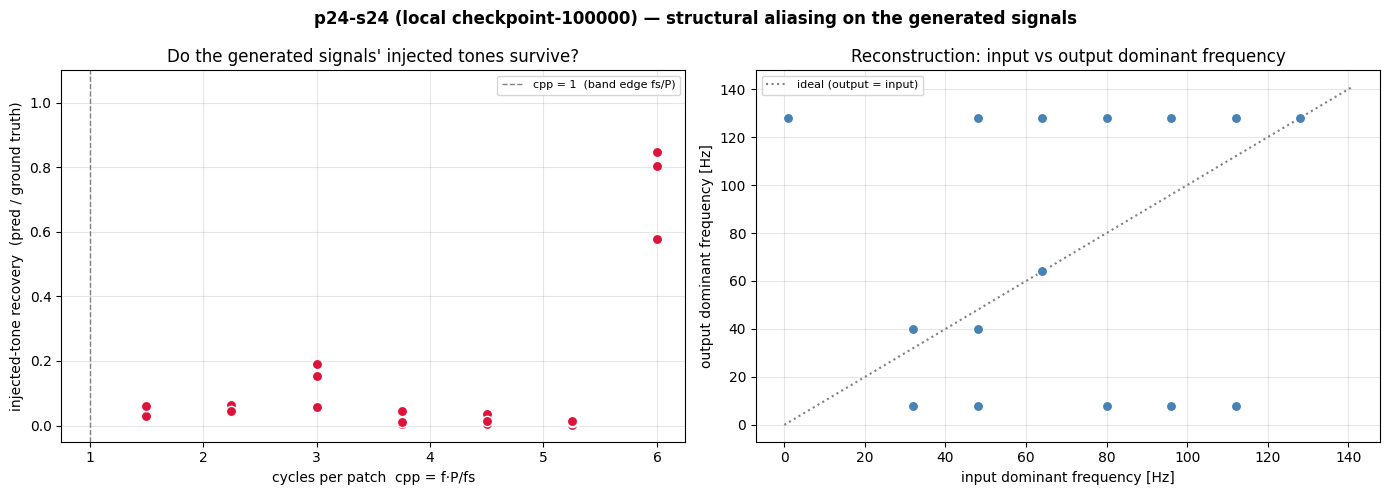


All injected tones sit at cpp > 1 (above the fs/P band edge): recovery is low, i.e. the generated signals land in the collapse band — the structural-aliasing ceiling, on real signals.


In [14]:
# __PERSIGNAL__  — reconstruction over the generated signals (paper Fig.5, per signal)
import re, glob
from pathlib import Path as _P

SIG_DIR = _P("../data/synthetic/signals")

def _parse_name(name):
    """fs and the injected (freq, amplitude) tones, read from the generator filename."""
    fs = int(re.search(r"fs(\d+)", name).group(1))
    tones = [(float(f), float(a)) for f, a in re.findall(r"hz([0-9.]+)_amp([0-9.]+)", name)]
    return fs, tones

def _fit_amp(y, t, f):
    X = np.stack([np.cos(2*np.pi*f*t), np.sin(2*np.pi*f*t), np.ones_like(t)], 1)
    a, b, _ = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(np.hypot(a, b))

def _dom_freq(y, fs):
    y = np.asarray(y, float) - np.mean(y)
    mag = np.abs(np.fft.rfft(y)); fr = np.fft.rfftfreq(len(y), d=1/fs)
    return float(fr[1:][np.argmax(mag[1:])]) if len(mag) > 1 else 0.0

files = sorted(glob.glob(str(SIG_DIR / "*.npy")))
print(f"{len(files)} generated signals in {SIG_DIR}\n")
print(f"{'freq':>7} {'fs':>4} {'cpp':>5} {'recovery':>8} {'inDom':>7} {'outDom':>7}  signal")
rows = []
for f in files:
    name = _P(f).name
    fs, tones = _parse_name(name)
    sig = np.load(f).astype(np.float32)
    ctx, gt = sig[:-PRED_LEN], sig[-PRED_LEN:]
    if len(ctx) < 60:
        continue
    pred = forecast_median(ctx)
    t_fut = (np.arange(len(sig)) / fs)[-PRED_LEN:]
    in_dom, out_dom = _dom_freq(sig, fs), _dom_freq(pred, fs)
    for (tf, ta) in tones:
        a_gt = _fit_amp(gt, t_fut, tf)
        rec = _fit_amp(pred, t_fut, tf) / a_gt if a_gt > 1e-8 else np.nan
        rows.append(dict(name=name, fs=fs, freq=tf, cpp=tf*P/fs, recovery=rec,
                         in_dom=in_dom, out_dom=out_dom))
        print(f"{tf:>7.1f} {fs:>4} {tf*P/fs:>5.2f} {rec:>8.3f} {in_dom:>7.1f} {out_dom:>7.1f}  {name[:44]}")

cpps  = np.array([r["cpp"] for r in rows]);      recs   = np.array([r["recovery"] for r in rows])
indom = np.array([r["in_dom"] for r in rows]);   outdom = np.array([r["out_dom"] for r in rows])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].axvline(1.0, color="grey", ls="--", lw=1, label="cpp = 1  (band edge fs/P)")
ax[0].scatter(cpps, recs, c="crimson", s=55, zorder=3, edgecolor="white")
ax[0].set_xlabel("cycles per patch  cpp = f·P/fs"); ax[0].set_ylabel("injected-tone recovery  (pred / ground truth)")
ax[0].set_title("Do the generated signals' injected tones survive?")
ax[0].set_ylim(-0.05, 1.1); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

lim = float(max(indom.max(), outdom.max())) * 1.1 if len(rows) else 1.0
ax[1].plot([0, lim], [0, lim], ls=":", color="grey", label="ideal (output = input)")
ax[1].scatter(indom, outdom, c="steelblue", s=55, zorder=3, edgecolor="white")
ax[1].set_xlabel("input dominant frequency [Hz]"); ax[1].set_ylabel("output dominant frequency [Hz]")
ax[1].set_title("Reconstruction: input vs output dominant frequency")
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)

fig.suptitle(f"{MODEL_LABEL} — structural aliasing on the generated signals", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "FIG5b_generated_signals.png", dpi=140, bbox_inches="tight"); plt.show()
print("\nAll injected tones sit at cpp > 1 (above the fs/P band edge): recovery is low, i.e. the "
      "generated signals land in the collapse band — the structural-aliasing ceiling, on real signals.")